In [1]:
# ============================================================
# DEMI Algorithm for Home Diagnosis of COVID-19
# ============================================================
#
# This script:
# 1. Loads the COVIDCARE patient data, DEMI knowledge base,
#    and survey dictionary.
# 2. Creates the PCR-confirmed analytic cohort.
# 3. Keeps information reasonably available at home.
# 4. Calculates DEMI pairwise odds ratios for PCR positivity.
# 5. Compares Logistic Regression, LASSO, and a boosting model.
# 6. Creates three figures for the final paper.

In [2]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import (
    accuracy_score, roc_auc_score, confusion_matrix,
    precision_score, recall_score, f1_score, roc_curve
)

# XGBoost is optional. If it is not installed, use sklearn boosting.
try:
    from xgboost import XGBClassifier
    USE_XGBOOST = True
except ImportError:
    from sklearn.ensemble import GradientBoostingClassifier
    USE_XGBOOST = False


# ============================================================
# 1. SETTINGS
# ============================================================

TARGET = "PCR Test Positive"
RANDOM_STATE = 42

# ============================================================
# 2. LOAD DATA
# ============================================================

df = pd.read_csv(r"C:\Users\hnali\Downloads\COVIDCARE_FORSUBMISSION_MIT_CLEANED_Phase_II_2021-12-03.csv")
kb = pd.read_csv(r"C:\Users\hnali\Downloads\COVIDCARE_DEMI_knowledgebase_v4.csv")
dictionary = pd.read_csv(r"C:\Users\hnali\Downloads\COVIDCARE_survey_dictionary_v2_ForSubmission_MIT_Phase_II_2021-12-26.csv")


In [3]:
# Remove accidental spaces from column names
df.columns = df.columns.astype(str).str.strip()
kb.columns = kb.columns.astype(str).str.strip()
dictionary.columns = dictionary.columns.astype(str).str.strip()

print("Patient data:", df.shape)
print("Knowledge base:", kb.shape)
print("Dictionary:", dictionary.shape)

# Check that the correct patient file was loaded
if TARGET not in df.columns:
    print("\nPCR-related columns found:")
    print([c for c in df.columns if "PCR" in c.upper()])
    raise ValueError(
        f"'{TARGET}' was not found. Make sure RAW_FILE points to the "
        "COVIDCARE patient-level CSV, not the knowledge base or dictionary."
    )


# ============================================================
# 3. CREATE THE ANALYTIC COHORT
# ============================================================

df[TARGET] = pd.to_numeric(df[TARGET], errors="coerce")

# A known PCR result is required for supervised model evaluation
model_df = df.dropna(subset=[TARGET]).copy()
model_df[TARGET] = model_df[TARGET].astype(int)

print("\nAnalytic cohort:", model_df.shape[0])
print(model_df[TARGET].value_counts().rename(index={0: "PCR negative", 1: "PCR positive"}))


# ============================================================
# 4. SELECT INFORMATION AVAILABLE AT HOME
# ============================================================
#
# The dictionary is used to remove obvious study administration,
# identifiers, dates, and PCR-result leakage.
#
# This keeps the code understandable while remaining consistent
# with the project's five-tier idea.

dictionary["Variable Name"] = dictionary["Variable Name"].astype(str).str.strip()

description_map = {}
for _, row in dictionary.iterrows():
    variable = row["Variable Name"]
    description = str(row.get("Description", ""))
    prompt = str(row.get("Prompt", ""))
    description_map[variable] = (description + " " + prompt).lower()

exclude_words = [
    "pcr",
    "internal id",
    "submission date",
    "deid",
    "email",
    "phone",
    "shipping",
    "payment",
    "consent",
    "research study",
    "tested positive for covid-19 in the last 30 days"
]


Patient data: (822, 472)
Knowledge base: (70983, 11)
Dictionary: (472, 10)

Analytic cohort: 559
PCR Test Positive
PCR negative    501
PCR positive     58
Name: count, dtype: int64


In [4]:
home_vars = []

for col in model_df.columns:
    if col == TARGET:
        continue

    text = (col + " " + description_map.get(col, "")).lower()

    # Remove obvious leakage / administrative variables
    if any(word in text for word in exclude_words):
        continue

    # Keep variables that have enough data to be useful
    if model_df[col].notna().sum() < 20:
        continue

    # Remove constant variables
    if model_df[col].nunique(dropna=True) < 2:
        continue

    home_vars.append(col)

print("\nHome-available predictors retained:", len(home_vars))


# ============================================================
# 5. FIVE-TIER SYSTEM
# ============================================================

def assign_tier(variable):
    """Assign a simple temporal tier based on variable description."""
    if variable == TARGET:
        return 4

    text = (variable + " " + description_map.get(variable, "")).lower()

    if any(x in text for x in ["at-home", "test strip", "pink line", "blue line"]):
        return 3

    if any(x in text for x in ["vaccine", "vaccination", "vaccinated", "flu shot"]):
        return 1

    if any(x in text for x in ["age", "gender", "race", "ethnicity", "birth sex"]):
        return 0

    return 2


tier_table = pd.DataFrame({
    "Variable": home_vars,
    "Tier": [assign_tier(v) for v in home_vars]
})

print("\nTier counts:")
print(tier_table["Tier"].value_counts().sort_index())


Home-available predictors retained: 381

Tier counts:
Tier
0     21
1     45
2    273
3     42
Name: count, dtype: int64


In [5]:
# ============================================================
# 6. DEMI PAIRWISE ASSOCIATIONS WITH PCR POSITIVITY
# ============================================================
#
# The knowledge base contains 2x2 counts for each concept pair.
# We calculate an odds ratio and log odds ratio for concepts whose target is PCR positivity.

pcr_kb = kb[kb["target_concept_code"] == "target_pcr_positive"].copy()

count_cols = [
    "n_code_target",
    "n_code_no_target",
    "n_target_no_code",
    "n_no_code_no_target"
]

for col in count_cols:
    pcr_kb[col] = pd.to_numeric(pcr_kb[col], errors="coerce").fillna(0)

# Haldane-Anscombe 0.5 correction prevents division by zero
pcr_kb["odds_ratio"] = (
    (pcr_kb["n_code_target"] + 0.5) *
    (pcr_kb["n_no_code_no_target"] + 0.5)
) / (
    (pcr_kb["n_code_no_target"] + 0.5) *
    (pcr_kb["n_target_no_code"] + 0.5)
)

pcr_kb["log_odds_ratio"] = np.log(pcr_kb["odds_ratio"])
pcr_kb["total_with_code"] = (
    pcr_kb["n_code_target"] + pcr_kb["n_code_no_target"]
)

# Avoid displaying extremely unstable effects based on tiny counts
demi_results = pcr_kb[pcr_kb["total_with_code"] >= 10].copy()
demi_results = demi_results.sort_values(
    "log_odds_ratio", key=lambda x: x.abs(), ascending=False
)

print("\nTop DEMI pairwise associations:")
print(
    demi_results[
        ["concept_code", "odds_ratio", "log_odds_ratio"]
    ].head(10).to_string(index=False)
)

demi_results.to_csv("DEMI_pairwise_results.csv", index=False)


# ============================================================
# 7. PREPARE DATA FOR MACHINE LEARNING
# ============================================================

X = model_df[home_vars].copy()
y = model_df[TARGET].copy()

categorical_cols = []
numeric_cols = []

for col in home_vars:
    if pd.api.types.is_numeric_dtype(X[col]) and X[col].nunique(dropna=True) > 10:
        numeric_cols.append(col)
    else:
        categorical_cols.append(col)

preprocess = ColumnTransformer([
    (
        "categorical",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]),
        categorical_cols
    ),
    (
        "numeric",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scale", StandardScaler())
        ]),
        numeric_cols
    )
])

print("Categorical variables:", len(categorical_cols))
print("Numeric variables:", len(numeric_cols))


Top DEMI pairwise associations:
               concept_code  odds_ratio  log_odds_ratio
 30141-covid_tst_symptoms-4   41.275862        3.720278
      31386-covid_results-1   37.434783        3.622600
30141-covid_tst_symptoms-15   37.330465        3.619810
30141-covid_tst_symptoms-23   35.734177        3.576108
 30141-covid_tst_symptoms-3   35.530878        3.570402
      30158-Symtpom_Neuro-7   34.647597        3.545228
      30158-Symtpom_Neuro-8   34.618100        3.544377
     target_athome_positive   33.401581        3.508603
 30141-covid_tst_symptoms-9   32.149941        3.470411
 30141-covid_tst_symptoms-8   29.791795        3.394233
Categorical variables: 377
Numeric variables: 4


In [6]:
# ============================================================
# 8. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE
)


# ============================================================
# 9. DEFINE THREE MODELS
# ============================================================

logistic = Pipeline([
    ("prep", preprocess),
    ("model", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        solver="liblinear"
    ))
])

lasso = Pipeline([
    ("prep", preprocess),
    ("model", LogisticRegressionCV(
        cv=5,
        penalty="l1",
        solver="saga",
        scoring="roc_auc",
        class_weight="balanced",
        max_iter=5000,
        random_state=RANDOM_STATE
    ))
])

if USE_XGBOOST:
    negative = (y_train == 0).sum()
    positive = (y_train == 1).sum()

    boosting = Pipeline([
        ("prep", preprocess),
        ("model", XGBClassifier(
            n_estimators=200,
            max_depth=3,
            learning_rate=0.05,
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            scale_pos_weight=negative / positive
        ))
    ])

    boosting_name = "XGBoost"

else:
    boosting = Pipeline([
        ("prep", preprocess),
        ("model", GradientBoostingClassifier(
            n_estimators=150,
            learning_rate=0.05,
            max_depth=3,
            random_state=RANDOM_STATE
        ))
    ])

    boosting_name = "Gradient Boosting"


models = {
    "Logistic Regression": logistic,
    "LASSO": lasso,
    boosting_name: boosting
}


In [7]:
# ============================================================
# 10. TRAIN AND EVALUATE MODELS
# ============================================================

results = []
probabilities = {}
fitted_models = {}
for name, model in models.items():

    print("\nTraining:", name)

    model.fit(X_train, y_train)
    fitted_models[name] = model

    probability = model.predict_proba(X_test)[:, 1]
    prediction = (probability >= 0.50).astype(int)

    probabilities[name] = probability

    tn, fp, fn, tp = confusion_matrix(
        y_test, prediction, labels=[0, 1]
    ).ravel()

    results.append({
        "Model": name,
        "AUC": roc_auc_score(y_test, probability),
        "Accuracy": accuracy_score(y_test, prediction),
        "Sensitivity": recall_score(y_test, prediction),
        "Specificity": tn / (tn + fp),
        "Precision": precision_score(y_test, prediction, zero_division=0),
        "F1": f1_score(y_test, prediction)
    })


results_df = pd.DataFrame(results).sort_values("AUC", ascending=False)

print("\nMODEL PERFORMANCE")
print(results_df.round(3).to_string(index=False))

results_df.to_csv("model_performance.csv", index=False)


Training: Logistic Regression

Training: LASSO

Training: XGBoost

MODEL PERFORMANCE
              Model   AUC  Accuracy  Sensitivity  Specificity  Precision    F1
            XGBoost 0.941     0.943        0.733        0.968      0.733 0.733
              LASSO 0.938     0.921        0.733        0.944      0.611 0.667
Logistic Regression 0.938     0.950        0.867        0.960      0.722 0.788


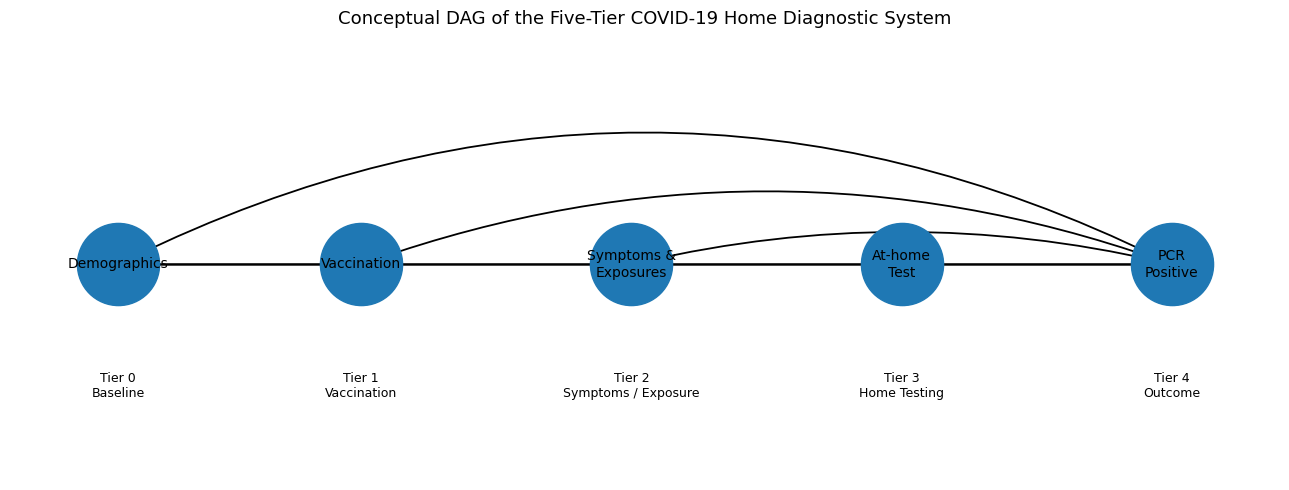

In [8]:
# ============================================================
# 11. FIGURE 1: CONCEPTUAL FIVE-TIER COVID-19 DAG
# ============================================================

import matplotlib.pyplot as plt
import networkx as nx

G = nx.DiGraph()

# Nodes
nodes = [
    "Demographics",
    "Vaccination",
    "Symptoms &\nExposures",
    "At-home\nTest",
    "PCR\nPositive"
]

G.add_nodes_from(nodes)

# Main temporal pathway
main_edges = [
    ("Demographics", "Vaccination"),
    ("Vaccination", "Symptoms &\nExposures"),
    ("Symptoms &\nExposures", "At-home\nTest"),
    ("At-home\nTest", "PCR\nPositive")
]

# Additional direct pathways to PCR
direct_edges = [
    ("Demographics", "PCR\nPositive"),
    ("Vaccination", "PCR\nPositive"),
    ("Symptoms &\nExposures", "PCR\nPositive")
]

G.add_edges_from(main_edges + direct_edges)

# Left-to-right layout
pos = {
    "Demographics": (0, 0),
    "Vaccination": (1.8, 0),
    "Symptoms &\nExposures": (3.8, 0),
    "At-home\nTest": (5.8, 0),
    "PCR\nPositive": (7.8, 0)
}

plt.figure(figsize=(13, 5))

# Draw nodes
nx.draw_networkx_nodes(
    G,
    pos,
    node_size=3500
)

# Draw labels
nx.draw_networkx_labels(
    G,
    pos,
    font_size=10
)

# Draw main temporal arrows
nx.draw_networkx_edges(
    G,
    pos,
    edgelist=main_edges,
    arrows=True,
    arrowsize=22,
    width=1.8,
    arrowstyle="-|>",
    connectionstyle="arc3,rad=0"
)

# Draw curved direct-effect arrows
nx.draw_networkx_edges(
    G,
    pos,
    edgelist=[("Demographics", "PCR\nPositive")],
    arrows=True,
    arrowsize=20,
    width=1.3,
    arrowstyle="-|>",
    connectionstyle="arc3,rad=-0.25"
)

nx.draw_networkx_edges(
    G,
    pos,
    edgelist=[("Vaccination", "PCR\nPositive")],
    arrows=True,
    arrowsize=20,
    width=1.3,
    arrowstyle="-|>",
    connectionstyle="arc3,rad=-0.18"
)

nx.draw_networkx_edges(
    G,
    pos,
    edgelist=[("Symptoms &\nExposures", "PCR\nPositive")],
    arrows=True,
    arrowsize=20,
    width=1.3,
    arrowstyle="-|>",
    connectionstyle="arc3,rad=-0.12"
)

# Tier labels under each node
tier_labels = {
    "Demographics": "Tier 0\nBaseline",
    "Vaccination": "Tier 1\nVaccination",
    "Symptoms &\nExposures": "Tier 2\nSymptoms / Exposure",
    "At-home\nTest": "Tier 3\nHome Testing",
    "PCR\nPositive": "Tier 4\nOutcome"
}

for node, label in tier_labels.items():
    x, y = pos[node]
    plt.text(
        x,
        y - 0.65,
        label,
        ha="center",
        va="top",
        fontsize=9
    )

plt.title(
    "Conceptual DAG of the Five-Tier COVID-19 Home Diagnostic System",
    fontsize=13
)

plt.xlim(-0.8, 8.6)
plt.ylim(-1.3, 1.4)
plt.axis("off")
plt.tight_layout()

plt.savefig(
    "Figure1_COVID_DAG_Final.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

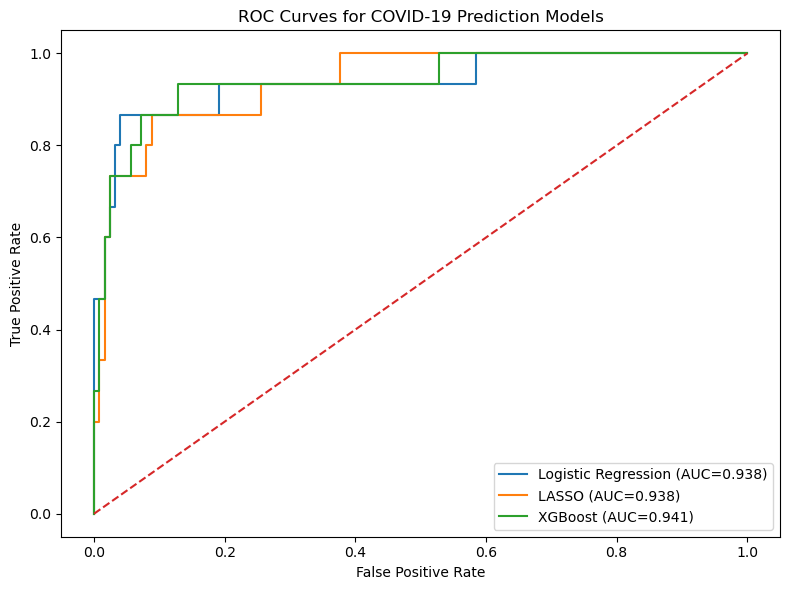

In [9]:
# ============================================================
# 12. FIGURE 2: ROC CURVES
# ============================================================

plt.figure(figsize=(8, 6))

for name, probability in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, probability)
    auc = roc_auc_score(y_test, probability)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for COVID-19 Prediction Models")
plt.legend()
plt.tight_layout()
plt.savefig("Figure2_ROC.png", dpi=300, bbox_inches="tight")
plt.show()

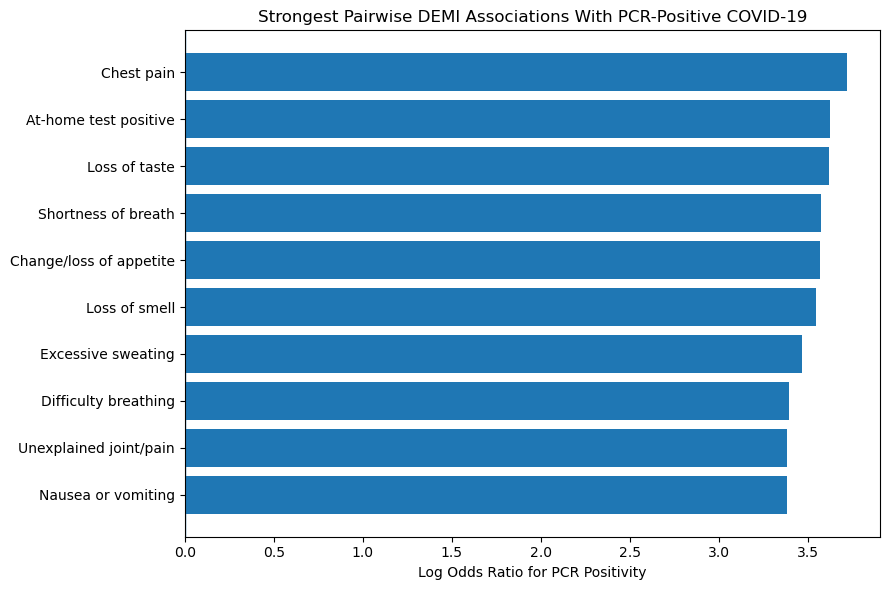

In [10]:
# ============================================================
# 13. FIGURE 3: TOP DEMI ASSOCIATIONS
# ============================================================

label_map = {
    "30141-covid_tst_symptoms-4": "Chest pain",
    "31386-covid_results-1": "At-home test positive",
    "30141-covid_tst_symptoms-15": "Loss of taste",
    "30141-covid_tst_symptoms-23": "Shortness of breath",
    "30141-covid_tst_symptoms-3": "Change/loss of appetite",
    "30158-Symtpom_Neuro-7": "Loss of smell",
    "30141-covid_tst_symptoms-9": "Excessive sweating",
    "30141-covid_tst_symptoms-8": "Difficulty breathing",
    "30141-covid_tst_symptoms-13": "Unexplained joint/pain",
    "30141-covid_tst_symptoms-29": "Nausea or vomiting"
}

plot_data = demi_results.copy()

plot_data["Clinical_Label"] = (
    plot_data["concept_code"]
    .map(label_map)
    .fillna(plot_data["concept_code"])
)

# Only use concepts that have meaningful clinical labels
plot_data = plot_data[
    plot_data["concept_code"].isin(label_map.keys())
].copy()

plot_data = plot_data.sort_values(
    "log_odds_ratio",
    ascending=True
)

plt.figure(figsize=(9, 6))

plt.barh(
    plot_data["Clinical_Label"],
    plot_data["log_odds_ratio"]
)

plt.xlabel("Log Odds Ratio for PCR Positivity")
plt.ylabel("")
plt.title(
    "Strongest Pairwise DEMI Associations With PCR-Positive COVID-19"
)

plt.axvline(0, linewidth=1)

plt.tight_layout()

plt.savefig(
    "Figure3_DEMI_Associations.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [11]:
# ============================================================
# 14. SIMPLE PATIENT-LEVEL PREDICTION
# ============================================================

best_model_name = results_df.iloc[0]["Model"]
best_model = fitted_models[best_model_name]

def predict_case(patient_information):
    """
    Estimate probability of PCR-positive COVID-19.

    Example:
        patient = {
            "AGE_VARIABLE_NAME": 30,
            "FEVER_VARIABLE_NAME": 1
        }
        predict_case(patient)
    """

    patient = pd.DataFrame(
        [{col: np.nan for col in home_vars}]
    )

    for variable, value in patient_information.items():
        if variable in patient.columns:
            patient.loc[0, variable] = value

    probability = best_model.predict_proba(patient)[0, 1]
    return probability


print("Best model by AUC:", best_model_name)
print("Analysis complete.")

Best model by AUC: XGBoost
Analysis complete.


In [12]:
# ============================================================
# 15. EXAMPLE PATIENT PREDICTION
# ============================================================

example_patient = {
    "30141-covid_tst_symptoms-11": 1,   # Fever
    "30141-covid_tst_symptoms-17": 1,   # Muscle aches
    "30141-covid_tst_symptoms-6": 1,    # Cough
    "30141-covid_tst_symptoms-15": 1    # Loss of taste
}

example_probability = predict_case(example_patient)

print("Example Patient")
print("----------------")
print("Fever: Yes")
print("Muscle aches: Yes")
print("Cough: Yes")
print("Loss of taste: Yes")

print(
    "\nPredicted probability of PCR-positive COVID-19:",
    round(example_probability * 100, 1),
    "%"
)

Example Patient
----------------
Fever: Yes
Muscle aches: Yes
Cough: Yes
Loss of taste: Yes

Predicted probability of PCR-positive COVID-19: 8.7 %
